In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns # Makes the style cleaner
from pathlib import Path
import polars as pl

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/responders.csv
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/sample_submission.csv
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/features.csv
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=4/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=5/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=6/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=3/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=1/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=8/part-0.parquet
/kaggle/input/competitions/ja

In [9]:
input_path = "/kaggle/input/competitions/jane-street-real-time-market-data-forecasting"
train_path = input_path + "/train.parquet/**/*.parquet"
data = pl.scan_parquet(train_path)
data

In [10]:
# Read Features CSV Data
features_path = input_path + "/features.csv"
features_data = pl.read_csv(features_path)
features_data

feature,tag_0,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,tag_10,tag_11,tag_12,tag_13,tag_14,tag_15,tag_16
str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""feature_00""",false,false,true,false,false,false,false,false,false,false,false,false,false,false,true,false,true
"""feature_01""",false,false,true,false,false,false,false,false,false,false,false,false,false,true,true,false,true
"""feature_02""",false,false,true,false,false,false,false,false,false,false,false,false,true,false,false,false,true
"""feature_03""",false,false,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true
"""feature_04""",false,false,true,false,false,false,false,false,false,false,false,false,true,true,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feature_74""",false,false,false,false,false,false,false,false,true,false,false,false,false,false,true,false,false
"""feature_75""",false,false,false,false,false,false,false,false,true,false,false,false,true,false,false,false,false
"""feature_76""",false,false,false,false,false,false,false,false,true,false,false,false,true,false,false,false,false


In [11]:
print(f"""
Features Columns: {features_data.columns}\n
Features Shape: {features_data.shape}
""")


Features Columns: ['feature', 'tag_0', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'tag_9', 'tag_10', 'tag_11', 'tag_12', 'tag_13', 'tag_14', 'tag_15', 'tag_16']

Features Shape: (79, 18)



In [12]:
# Read Responders CSV Data
responders_path = input_path + "/responders.csv"
responders_data = pl.read_csv(responders_path)
responders_data

responder,tag_0,tag_1,tag_2,tag_3,tag_4
str,bool,bool,bool,bool,bool
"""responder_0""",true,false,true,false,false
"""responder_1""",true,false,false,true,false
"""responder_2""",true,true,false,false,false
"""responder_3""",false,false,true,false,true
"""responder_4""",false,false,false,true,true
"""responder_5""",false,true,false,false,true
"""responder_6""",false,false,true,false,false
"""responder_7""",false,false,false,true,false
"""responder_8""",false,true,false,false,false


In [13]:
print(f"""
Responder Columns: {responders_data.columns}\n
Responder Shape: {responders_data.shape}
""")


Responder Columns: ['responder', 'tag_0', 'tag_1', 'tag_2', 'tag_3', 'tag_4']

Responder Shape: (9, 6)



DATASET SHAPE AND METADATA SCAN
Total columns    : 92
Feature columns  : 79  (feature_00 ... feature_78)
Responder columns: 9  (responder_0, responder_1, responder_2, responder_3, responder_4, responder_5, responder_6, responder_7, responder_8)
Other columns    : date_id, time_id, symbol_id, weight
Target column    : responder_6

shape: (1, 5)
┌────────────┬──────────────┬────────────────┬──────────┬──────────┐
│ total_rows ┆ unique_dates ┆ unique_symbols ┆ date_min ┆ date_max │
│ ---        ┆ ---          ┆ ---            ┆ ---      ┆ ---      │
│ u32        ┆ u32          ┆ u32            ┆ i16      ┆ i16      │
╞════════════╪══════════════╪════════════════╪══════════╪══════════╡
│ 47127338   ┆ 1699         ┆ 39             ┆ 0        ┆ 1698     │
└────────────┴──────────────┴────────────────┴──────────┴──────────┘

Total rows       : 47,127,338
Unique dates     : 1699
Unique symbols   : 39
Date range       : 0 → 1698
Avg symbols/date : 27738.3

MISSING-VALUE AUDIT
Columns with any n

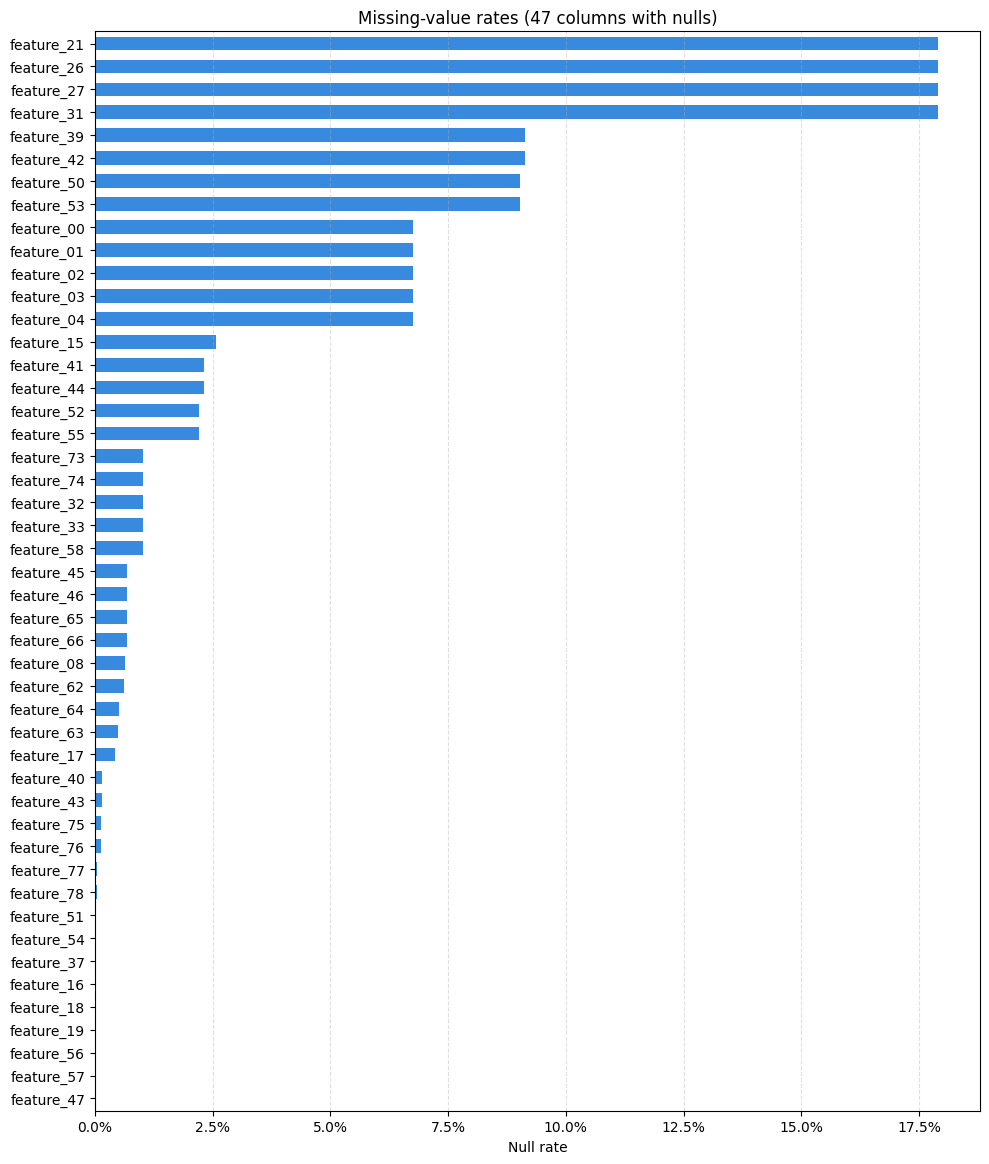

Chart saved → results/eda/01_missing_rates.png

TARGET DISTRIBUTION AND WINSORISATION BOUNDS


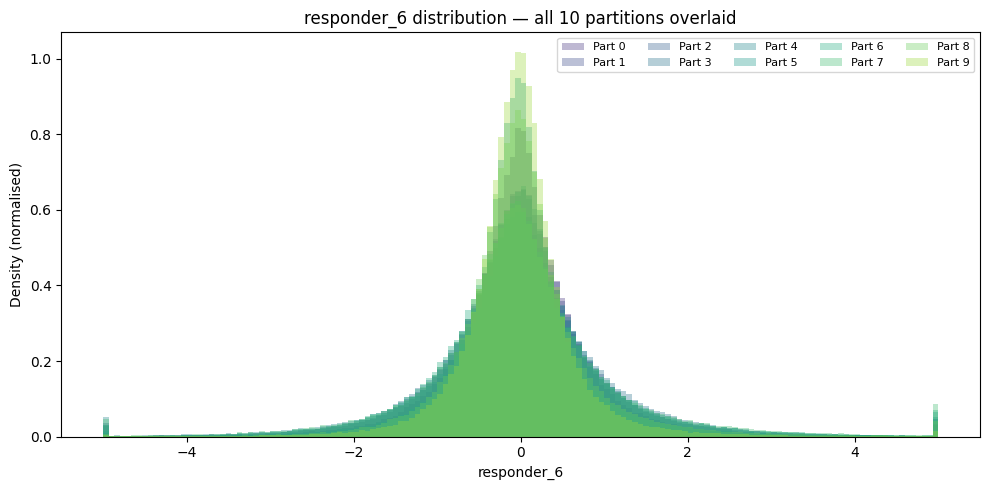


Kurtosis per partition:
  Partition 0: kurtosis = 5.98
  Partition 1: kurtosis = 4.71
  Partition 2: kurtosis = 4.65
  Partition 3: kurtosis = 3.77
  Partition 4: kurtosis = 4.21
  Partition 5: kurtosis = 8.47
  Partition 6: kurtosis = 4.35
  Partition 7: kurtosis = 4.09
  Partition 8: kurtosis = 7.47
  Partition 9: kurtosis = 9.64


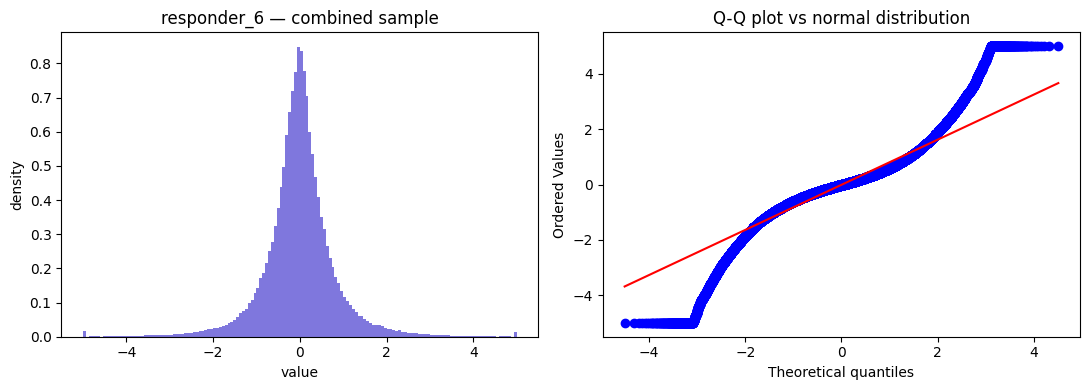


Combined sample statistics:
  Kurtosis      : 5.95  (normal=0, fat tails >> 0)
  Skewness      : 0.0208  (0=symmetric)
  WINSOR_LOWER  : -2.547142
  WINSOR_UPPER  : 2.549128

Charts saved → results/eda/02_target_dist_all_partitions.png
               → results/eda/03_target_qq.png

SYMBOL UNIVERSE STABILITY OVER TIME
Symbols per date - min: 4, max: 39, mean: 29.7


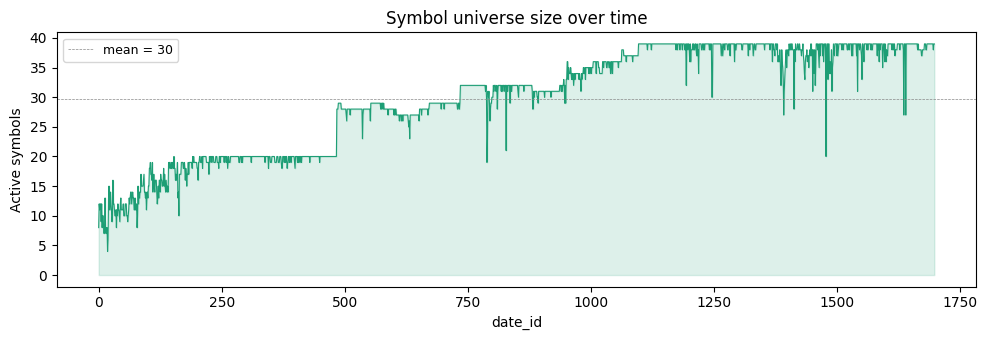

Chart saved → results/eda/04_universe_stability.png

EDA BLOCK COMPLETE
TARGET_COL           = responder_6
N_ROWS               = 47127338
N_DATES              = 1699
N_SYMBOLS            = 39
DATE_MIN             = 0
DATE_MAX             = 1698
WINSOR_LOWER         = -2.547142
WINSOR_UPPER         = 2.549128
TARGET_KURTOSIS      = 5.949999809265137
TARGET_SKEWNESS      = 0.020800000056624413
{'TARGET_COL': 'responder_6', 'N_ROWS': 47127338, 'N_DATES': 1699, 'N_SYMBOLS': 39, 'DATE_MIN': 0, 'DATE_MAX': 1698, 'WINSOR_LOWER': np.float64(-2.547142), 'WINSOR_UPPER': np.float64(2.549128), 'TARGET_KURTOSIS': np.float32(5.95), 'TARGET_SKEWNESS': np.float32(0.0208), 'KURTOSIS_PER_PARTITION': {0: np.float32(5.98), 1: np.float32(4.71), 2: np.float32(4.65), 3: np.float32(3.77), 4: np.float32(4.21), 5: np.float32(8.47), 6: np.float32(4.35), 7: np.float32(4.09), 8: np.float32(7.47), 9: np.float32(9.64)}}


In [15]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats
from pathlib import Path


TRAIN_PATH = "/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet"
TARGET_COL = "responder_6"
RESULTS_DIR = Path("results/eda")


def perform_eda():
    """
    Covers all 4 tasks related to EDA for the Alpha Factor Discovery Engine.:
      -> Dataset shape and metadata scan
      -> Missing-value audit across all partitions
      -> Target distribution and winsorisation bounds
      -> Symbol universe stability over time
    
    All charts are saved to results/eda/ for the GitHub README.
    Returns a dict of key findings to copy into config.py.
    """
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    # Lazy scan of full dataset — nothing loaded into RAM yet
    lf = pl.scan_parquet(f"{TRAIN_PATH}/**/part-0.parquet")
    columns = lf.collect_schema().names()

    # ══════════════════════════════════════════════════════════════════════
    # DATASET SHAPE AND METADATA SCAN
    # ══════════════════════════════════════════════════════════════════════
    print("=" * 70)
    print("DATASET SHAPE AND METADATA SCAN")
    print("=" * 70)

    # Column classification
    feature_cols   = [c for c in columns if c.startswith("feature_")]
    responder_cols = [c for c in columns if c.startswith("responder_")]

    print(f"Total columns    : {len(columns)}")
    print(f"Feature columns  : {len(feature_cols)}  (feature_00 ... feature_{len(feature_cols)-1:02d})")
    print(f"Responder columns: {len(responder_cols)}  ({', '.join(responder_cols)})")
    print(f"Other columns    : date_id, time_id, symbol_id, weight")
    print(f"Target column    : {TARGET_COL}")

    # Cardinality - streams through all partitions, returns 1 row
    shape_stats = (
        lf.select([
            pl.len().alias("total_rows"),
            pl.col("date_id").n_unique().alias("unique_dates"),
            pl.col("symbol_id").n_unique().alias("unique_symbols"),
            pl.col("date_id").min().alias("date_min"),
            pl.col("date_id").max().alias("date_max"),
        ])
        .collect()
    )
    print(f"\n{shape_stats}")

    n_rows   = shape_stats["total_rows"][0]
    n_dates  = shape_stats["unique_dates"][0]
    n_symbols = shape_stats["unique_symbols"][0]
    date_min = shape_stats["date_min"][0]
    date_max = shape_stats["date_max"][0]

    print(f"\nTotal rows       : {n_rows:,}")
    print(f"Unique dates     : {n_dates}")
    print(f"Unique symbols   : {n_symbols}")
    print(f"Date range       : {date_min} → {date_max}")
    print(f"Avg symbols/date : {n_rows / n_dates:.1f}")


    # ══════════════════════════════════════════════════════════════════════
    # MISSING-VALUE AUDIT ACROSS ALL PARTITIONS
    # ══════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 70)
    print("MISSING-VALUE AUDIT")
    print("=" * 70)

    missing_rates = (
        lf.select(pl.all().is_null().mean())
        .collect()
        .unpivot()
        .rename({"variable": "column", "value": "null_rate"})
        .sort("null_rate", descending=True)
    )

    cols_with_nulls = missing_rates.filter(pl.col("null_rate") > 0).height
    cols_above_10pct = missing_rates.filter(pl.col("null_rate") > 0.10).height
    print(f"Columns with any nulls : {cols_with_nulls} / {len(columns)}")
    print(f"Columns with >10% null : {cols_above_10pct}")

    # Show top 20
    with pl.Config(tbl_rows=20):
        print(f"\nTop 20 by null rate:\n{missing_rates.head(20)}")

    # Plot - only columns with nulls, sorted so largest bars at top
    df_plot = missing_rates.filter(pl.col("null_rate") > 0).sort("null_rate", descending=False)
    num_cols = df_plot.height
    dynamic_height = max(6, num_cols * 0.25)

    fig, ax = plt.subplots(figsize=(10, dynamic_height))
    ax.barh(df_plot["column"].to_list(), df_plot["null_rate"].to_list(),
            color="#378ADD", height=0.6)
    ax.set_xlabel("Null rate")
    ax.set_title(f"Missing-value rates ({num_cols} columns with nulls)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.margins(y=0.005)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "01_missing_rates.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved → {RESULTS_DIR / '01_missing_rates.png'}")


    # ══════════════════════════════════════════════════════════════════════
    # TARGET DISTRIBUTION AND WINSORISATION BOUNDS
    # ══════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 70)
    print("TARGET DISTRIBUTION AND WINSORISATION BOUNDS")
    print("=" * 70)

    # Chart 1: all 10 partitions overlaid
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, 10))
    kurtosis_per_part = []

    for i in range(10):
        file_path = f"{TRAIN_PATH}/partition_id={i}/part-0.parquet"
        vals = pl.read_parquet(file_path, n_rows=200_000)[TARGET_COL].drop_nulls().to_numpy()
        ax.hist(vals, bins=150, alpha=0.35, color=colors[i], label=f"Part {i}",
                density=True, histtype="stepfilled")
        kurtosis_per_part.append(stats.kurtosis(vals))

    ax.set_xlabel(TARGET_COL)
    ax.set_ylabel("Density (normalised)")
    ax.set_title(f"{TARGET_COL} distribution — all 10 partitions overlaid")
    ax.legend(fontsize=8, ncol=5)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "02_target_dist_all_partitions.png", dpi=150)
    plt.show()

    print("\nKurtosis per partition:")
    for i, k in enumerate(kurtosis_per_part):
        print(f"  Partition {i}: kurtosis = {k:.2f}")

    # Chart 2: Q-Q plot on combined sample (early + mid + late partitions)
    combined = []
    for i in [0, 4, 9]:
        file_path = f"{TRAIN_PATH}/partition_id={i}/part-0.parquet"
        combined.append(
            pl.read_parquet(file_path, n_rows=70_000)[TARGET_COL].drop_nulls().to_numpy()
        )
    target_sample = np.concatenate(combined)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(target_sample, bins=150, color="#7F77DD", edgecolor="none", density=True)
    axes[0].set_title(f"{TARGET_COL} — combined sample")
    axes[0].set_xlabel("value")
    axes[0].set_ylabel("density")

    stats.probplot(target_sample, dist="norm", plot=axes[1])
    axes[1].set_title("Q-Q plot vs normal distribution")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "03_target_qq.png", dpi=150)
    plt.show()

    # Compute final statistics
    kurt = stats.kurtosis(target_sample)
    skew = stats.skew(target_sample)
    p01, p99 = np.percentile(target_sample, [1, 99])

    print(f"\nCombined sample statistics:")
    print(f"  Kurtosis      : {kurt:.2f}  (normal=0, fat tails >> 0)")
    print(f"  Skewness      : {skew:.4f}  (0=symmetric)")
    print(f"  WINSOR_LOWER  : {p01:.6f}")
    print(f"  WINSOR_UPPER  : {p99:.6f}")
    print(f"\nCharts saved → {RESULTS_DIR / '02_target_dist_all_partitions.png'}")
    print(f"               → {RESULTS_DIR / '03_target_qq.png'}")


    # ══════════════════════════════════════════════════════════════════════
    # SYMBOL UNIVERSE STABILITY OVER TIME
    # ══════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 70)
    print("SYMBOL UNIVERSE STABILITY OVER TIME")
    print("=" * 70)

    symbols_per_date = (
        lf.group_by("date_id")
        .agg(pl.col("symbol_id").n_unique().alias("n_symbols"))
        .sort("date_id")
        .collect()
    )

    min_sym = symbols_per_date["n_symbols"].min()
    max_sym = symbols_per_date["n_symbols"].max()
    mean_sym = symbols_per_date["n_symbols"].mean()

    print(f"Symbols per date - min: {min_sym}, max: {max_sym}, mean: {mean_sym:.1f}")

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(symbols_per_date["date_id"].to_list(),
            symbols_per_date["n_symbols"].to_list(),
            linewidth=0.8, color="#1D9E75")
    ax.fill_between(symbols_per_date["date_id"].to_list(),
                     symbols_per_date["n_symbols"].to_list(),
                     alpha=0.15, color="#1D9E75")
    ax.set_xlabel("date_id")
    ax.set_ylabel("Active symbols")
    ax.set_title("Symbol universe size over time")
    ax.axhline(mean_sym, color="#888", linewidth=0.5, linestyle="--", label=f"mean = {mean_sym:.0f}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "04_universe_stability.png", dpi=150)
    plt.show()
    print(f"Chart saved → {RESULTS_DIR / '04_universe_stability.png'}")


    # ══════════════════════════════════════════════════════════════════════
    # SUMMARY - findings for config.py
    # ══════════════════════════════════════════════════════════════════════
    findings = {
        "TARGET_COL":     TARGET_COL,
        "N_ROWS":         n_rows,
        "N_DATES":        n_dates,
        "N_SYMBOLS":      n_symbols,
        "DATE_MIN":       date_min,
        "DATE_MAX":       date_max,
        "WINSOR_LOWER":   round(p01, 6),
        "WINSOR_UPPER":   round(p99, 6),
        "TARGET_KURTOSIS": round(kurt, 2),
        "TARGET_SKEWNESS": round(skew, 4),
        "KURTOSIS_PER_PARTITION": {i: round(k, 2) for i, k in enumerate(kurtosis_per_part)},
    }

    print("\n" + "=" * 70)
    print("EDA BLOCK COMPLETE")
    print("=" * 70)
    for key, val in findings.items():
        if key != "KURTOSIS_PER_PARTITION":
            print(f"{key:20s} = {val}")

    return findings


# ── Run ───────────────────────────────────────────────────────────────────────
findings = perform_eda()
print(findings)